# Variational Autoencoder with PyTorch 

In [84]:
pip install torch torchvision

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: C:\Users\BOUKA\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Imports 

In [85]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import os
for dirname, _, filenames in os.walk('/inputs'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import nn, optim
from torch.autograd import Variable
from sklearn.decomposition import PCA

import pandas as pd
import numpy as np
from sklearn import preprocessing

# Any results you write to the current directory are saved as output.

In [86]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

## Get a quick view of the data 

In [87]:
DATA_PATH = r'C:\Users\BOUKA\Downloads\VAE-Code\inputs\hepatitis_csv.csv'
df = pd.read_csv(DATA_PATH, sep=',')
#df=df.dropna()
df.columns

Index(['age', 'sex', 'steroid', 'antivirals', 'fatigue', 'malaise', 'anorexia',
       'liver_big', 'liver_firm', 'spleen_palpable', 'spiders', 'ascites',
       'varices', 'bilirubin', 'alk_phosphate', 'sgot', 'albumin', 'protime',
       'histology', 'class'],
      dtype='object')

## Process datasets

### Hepatitis dataset

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

In [89]:
#DATA_PATH = 'inputs/diabetes.csv'
#df = pd.read_csv(DATA_PATH, sep=',')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              155 non-null    int64  
 1   sex              155 non-null    object 
 2   steroid          154 non-null    object 
 3   antivirals       155 non-null    bool   
 4   fatigue          154 non-null    object 
 5   malaise          154 non-null    object 
 6   anorexia         154 non-null    object 
 7   liver_big        145 non-null    object 
 8   liver_firm       144 non-null    object 
 9   spleen_palpable  150 non-null    object 
 10  spiders          150 non-null    object 
 11  ascites          150 non-null    object 
 12  varices          150 non-null    object 
 13  bilirubin        149 non-null    float64
 14  alk_phosphate    126 non-null    float64
 15  sgot             151 non-null    float64
 16  albumin          139 non-null    float64
 17  protime         

In [90]:
df['class'].value_counts()

class
live    123
die      32
Name: count, dtype: int64

We replace {"live", "die"} by {0, 1} in the column `class`

In [91]:
df['class'].replace("live", 0, inplace=True)
df['class'].replace("die", 1, inplace=True)

In [92]:
df['class'].value_counts()

class
0    123
1     32
Name: count, dtype: int64

In [93]:
df.describe()

,age,bilirubin,alk_phosphate,sgot,albumin,protime,class
count,155.000000,149.000000,126.000000,151.00000,139.000000,88.000000,155.000000
mean,41.200000,1.427517,105.325397,85.89404,3.817266,61.852273,0.206452
std,12.565878,1.212149,51.508109,89.65089,0.651523,22.875244,0.406070
min,7.000000,0.300000,26.000000,14.00000,2.100000,0.000000,0.000000
25%,32.000000,0.700000,74.250000,31.50000,3.400000,46.000000,0.000000
50%,39.000000,1.000000,85.000000,58.00000,4.000000,61.000000,0.000000
75%,50.000000,1.500000,132.250000,100.50000,4.200000,76.250000,0.000000
max,78.000000,8.000000,295.000000,648.00000,6.400000,100.000000,1.000000


In [94]:
df.rename(columns={"class": "Outcome"}, inplace=True)

In [95]:
df.columns

Index(['age', 'sex', 'steroid', 'antivirals', 'fatigue', 'malaise', 'anorexia',
       'liver_big', 'liver_firm', 'spleen_palpable', 'spiders', 'ascites',
       'varices', 'bilirubin', 'alk_phosphate', 'sgot', 'albumin', 'protime',
       'histology', 'Outcome'],
      dtype='object')

#### Null Values

<Axes: >

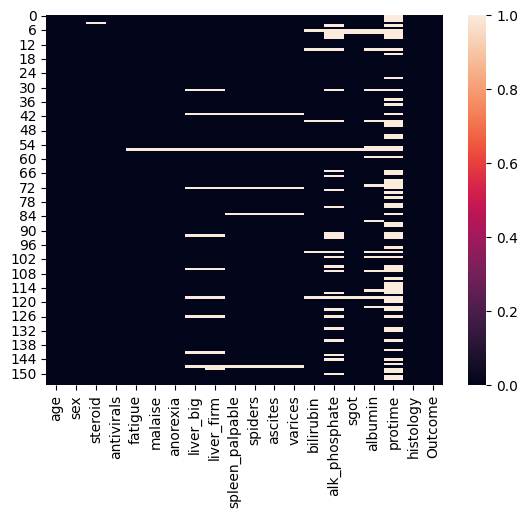

In [96]:
sns.heatmap(df.isnull())

In [97]:
df.isnull().sum()

age                 0
sex                 0
steroid             1
antivirals          0
fatigue             1
malaise             1
anorexia            1
liver_big          10
liver_firm         11
spleen_palpable     5
spiders             5
ascites             5
varices             5
bilirubin           6
alk_phosphate      29
sgot                4
albumin            16
protime            67
histology           0
Outcome             0
dtype: int64

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              155 non-null    int64  
 1   sex              155 non-null    object 
 2   steroid          154 non-null    object 
 3   antivirals       155 non-null    bool   
 4   fatigue          154 non-null    object 
 5   malaise          154 non-null    object 
 6   anorexia         154 non-null    object 
 7   liver_big        145 non-null    object 
 8   liver_firm       144 non-null    object 
 9   spleen_palpable  150 non-null    object 
 10  spiders          150 non-null    object 
 11  ascites          150 non-null    object 
 12  varices          150 non-null    object 
 13  bilirubin        149 non-null    float64
 14  alk_phosphate    126 non-null    float64
 15  sgot             151 non-null    float64
 16  albumin          139 non-null    float64
 17  protime         

In [99]:
df.describe()

,age,bilirubin,alk_phosphate,sgot,albumin,protime,Outcome
count,155.000000,149.000000,126.000000,151.00000,139.000000,88.000000,155.000000
mean,41.200000,1.427517,105.325397,85.89404,3.817266,61.852273,0.206452
std,12.565878,1.212149,51.508109,89.65089,0.651523,22.875244,0.406070
min,7.000000,0.300000,26.000000,14.00000,2.100000,0.000000,0.000000
25%,32.000000,0.700000,74.250000,31.50000,3.400000,46.000000,0.000000
50%,39.000000,1.000000,85.000000,58.00000,4.000000,61.000000,0.000000
75%,50.000000,1.500000,132.250000,100.50000,4.200000,76.250000,0.000000
max,78.000000,8.000000,295.000000,648.00000,6.400000,100.000000,1.000000


In [100]:
for col in df.columns:
    print(df[col].value_counts())

age
30    8
34    8
38    8
36    7
51    6
39    6
50    6
42    5
54    5
45    5
44    5
28    5
37    5
32    4
47    4
27    4
31    4
23    4
41    3
56    3
33    3
52    3
20    3
40    3
61    3
25    3
49    3
35    2
22    2
48    2
57    2
24    2
58    2
62    2
78    1
53    1
46    1
70    1
72    1
69    1
7     1
65    1
64    1
60    1
59    1
67    1
26    1
66    1
43    1
Name: count, dtype: int64
sex
female    139
male       16
Name: count, dtype: int64
steroid
True     78
False    76
Name: count, dtype: int64
antivirals
False    131
True      24
Name: count, dtype: int64
fatigue
True     100
False     54
Name: count, dtype: int64
malaise
False    93
True     61
Name: count, dtype: int64
anorexia
False    122
True      32
Name: count, dtype: int64
liver_big
True     120
False     25
Name: count, dtype: int64
liver_firm
False    84
True     60
Name: count, dtype: int64
spleen_palpable
False    120
True      30
Name: count, dtype: int64
spiders
False    99
True     

In [101]:
df.head()

,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver_big,liver_firm,spleen_palpable,spiders,ascites,varices,bilirubin,alk_phosphate,sgot,albumin,protime,histology,Outcome
0,30,male,False,False,False,False,False,False,False,False,False,False,False,1.0,85.0,18.0,4.0,NaN,False,0
1,50,female,False,False,True,False,False,False,False,False,False,False,False,0.9,135.0,42.0,3.5,NaN,False,0
2,78,female,True,False,True,False,False,True,False,False,False,False,False,0.7,96.0,32.0,4.0,NaN,False,0
3,31,female,NaN,True,False,False,False,True,False,False,False,False,False,0.7,46.0,52.0,4.0,80.0,False,0
4,34,female,True,False,False,False,False,True,False,False,False,False,False,1.0,NaN,200.0,4.0,NaN,False,0


In [102]:
print(type(df['liver_firm'][0]))

<class 'bool'>


#### Handling missing values with imputation with median

In [103]:
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols

Index(['sex', 'steroid', 'fatigue', 'malaise', 'anorexia', 'liver_big',
       'liver_firm', 'spleen_palpable', 'spiders', 'ascites', 'varices'],
      dtype='object')

In [104]:
# Step 2: Impute missing values using the mode for each categorical column
for column in categorical_cols:
    mode_value = df[column].mode()[0]
    df[column].fillna(mode_value, inplace=True)

In [105]:
mapping_1 = {"male": 0, "female": 1}
mapping_2 = {True: 1, False: 0}
df['sex'] = df['sex'].map(mapping_1)
for col in categorical_cols[1:]:
    df[col] = df[col].map(mapping_2)

In [106]:
for col in categorical_cols:
    print(df[col].value_counts())

sex
1    139
0     16
Name: count, dtype: int64
steroid
1    79
0    76
Name: count, dtype: int64
fatigue
1    101
0     54
Name: count, dtype: int64
malaise
0    94
1    61
Name: count, dtype: int64
anorexia
0    123
1     32
Name: count, dtype: int64
liver_big
1    130
0     25
Name: count, dtype: int64
liver_firm
0    95
1    60
Name: count, dtype: int64
spleen_palpable
0    125
1     30
Name: count, dtype: int64
spiders
0    104
1     51
Name: count, dtype: int64
ascites
0    135
1     20
Name: count, dtype: int64
varices
0    137
1     18
Name: count, dtype: int64


9
['albumin', 'Outcome', 'protime', 'antivirals', 'bilirubin', 'age', 'histology', 'sgot', 'alk_phosphate']


<Axes: >

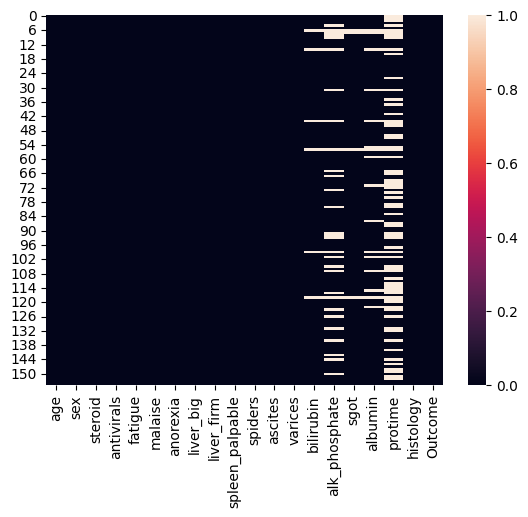

In [107]:
num_cols = list(set(df.columns) -set(categorical_cols))
print(len(num_cols))
print(num_cols)

sns.heatmap(df.isnull())

In [108]:
print(f"null values before imputation: {df['protime'].isnull().sum()}")
median_protime = df['protime'].median()
print(f"median of the column protime is {median_protime}")
df['protime'].fillna(median_protime, inplace=True)
num_nans_after = df['protime'].isnull().sum()
print(f"Number of NaNs in 'protime' after imputation {num_nans_after}")

null values before imputation: 67
median of the column protime is 61.0
Number of NaNs in 'protime' after imputation 0


In [109]:
df['albumin'].isnull().sum()
print(f"null values before imputation: {df['albumin'].isnull().sum()}")
median_albumin = df['albumin'].median()
df['albumin'].fillna(median_albumin, inplace=True)
num_nans_after = df['albumin'].isnull().sum()
print(f"Number of NaNs in 'albumin' after imputation {num_nans_after}")

null values before imputation: 16
Number of NaNs in 'albumin' after imputation 0


In [110]:
df['sgot'].isnull().sum()
print(f"null values before imputation: {df['sgot'].isnull().sum()}")
median_sgot = df['sgot'].median()
df['sgot'].fillna(median_sgot, inplace=True)
num_nans_after = df['sgot'].isnull().sum()
print(f"Number of NaNs in 'sgot' after imputation {num_nans_after}")

null values before imputation: 4
Number of NaNs in 'sgot' after imputation 0


In [111]:
df['sgot'].isnull().sum()
print(f"null values before imputation: {df['sgot'].isnull().sum()}")
median_sgot = df['sgot'].median()
df['sgot'].fillna(median_sgot, inplace=True)
num_nans_after = df['sgot'].isnull().sum()
print(f"Number of NaNs in 'sgot' after imputation {num_nans_after}")

null values before imputation: 0
Number of NaNs in 'sgot' after imputation 0


In [112]:
#alk_phosphate
df['alk_phosphate'].isnull().sum()
print(f"null values before imputation: {df['alk_phosphate'].isnull().sum()}")
median_alk_phosphate = df['alk_phosphate'].median()
df['alk_phosphate'].fillna(median_alk_phosphate, inplace=True)
num_nans_after = df['alk_phosphate'].isnull().sum()
print(f"Number of NaNs in 'alk_phosphate' after imputation {num_nans_after}")

null values before imputation: 29
Number of NaNs in 'alk_phosphate' after imputation 0


In [113]:
#bilirubin
df['bilirubin'].isnull().sum()
print(f"null values before imputation: {df['bilirubin'].isnull().sum()}")
median_bilirubin = df['bilirubin'].median()
df['bilirubin'].fillna(median_bilirubin, inplace=True)
num_nans_after = df['bilirubin'].isnull().sum()
print(f"Number of NaNs in 'bilirubin' after imputation {num_nans_after}")

null values before imputation: 6
Number of NaNs in 'bilirubin' after imputation 0


<Axes: >

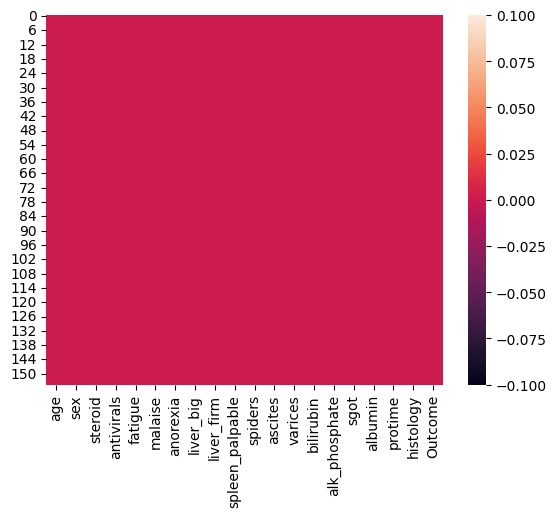

In [114]:
sns.heatmap(df.isnull())

#### Cleansing the data: removing outliers

In [115]:
df['Outcome'].nunique
df['Outcome'].value_counts()

Outcome
0    123
1     32
Name: count, dtype: int64

* **There are two classes: 0 is 'live' and 1 is 'die'**

### Visualizations

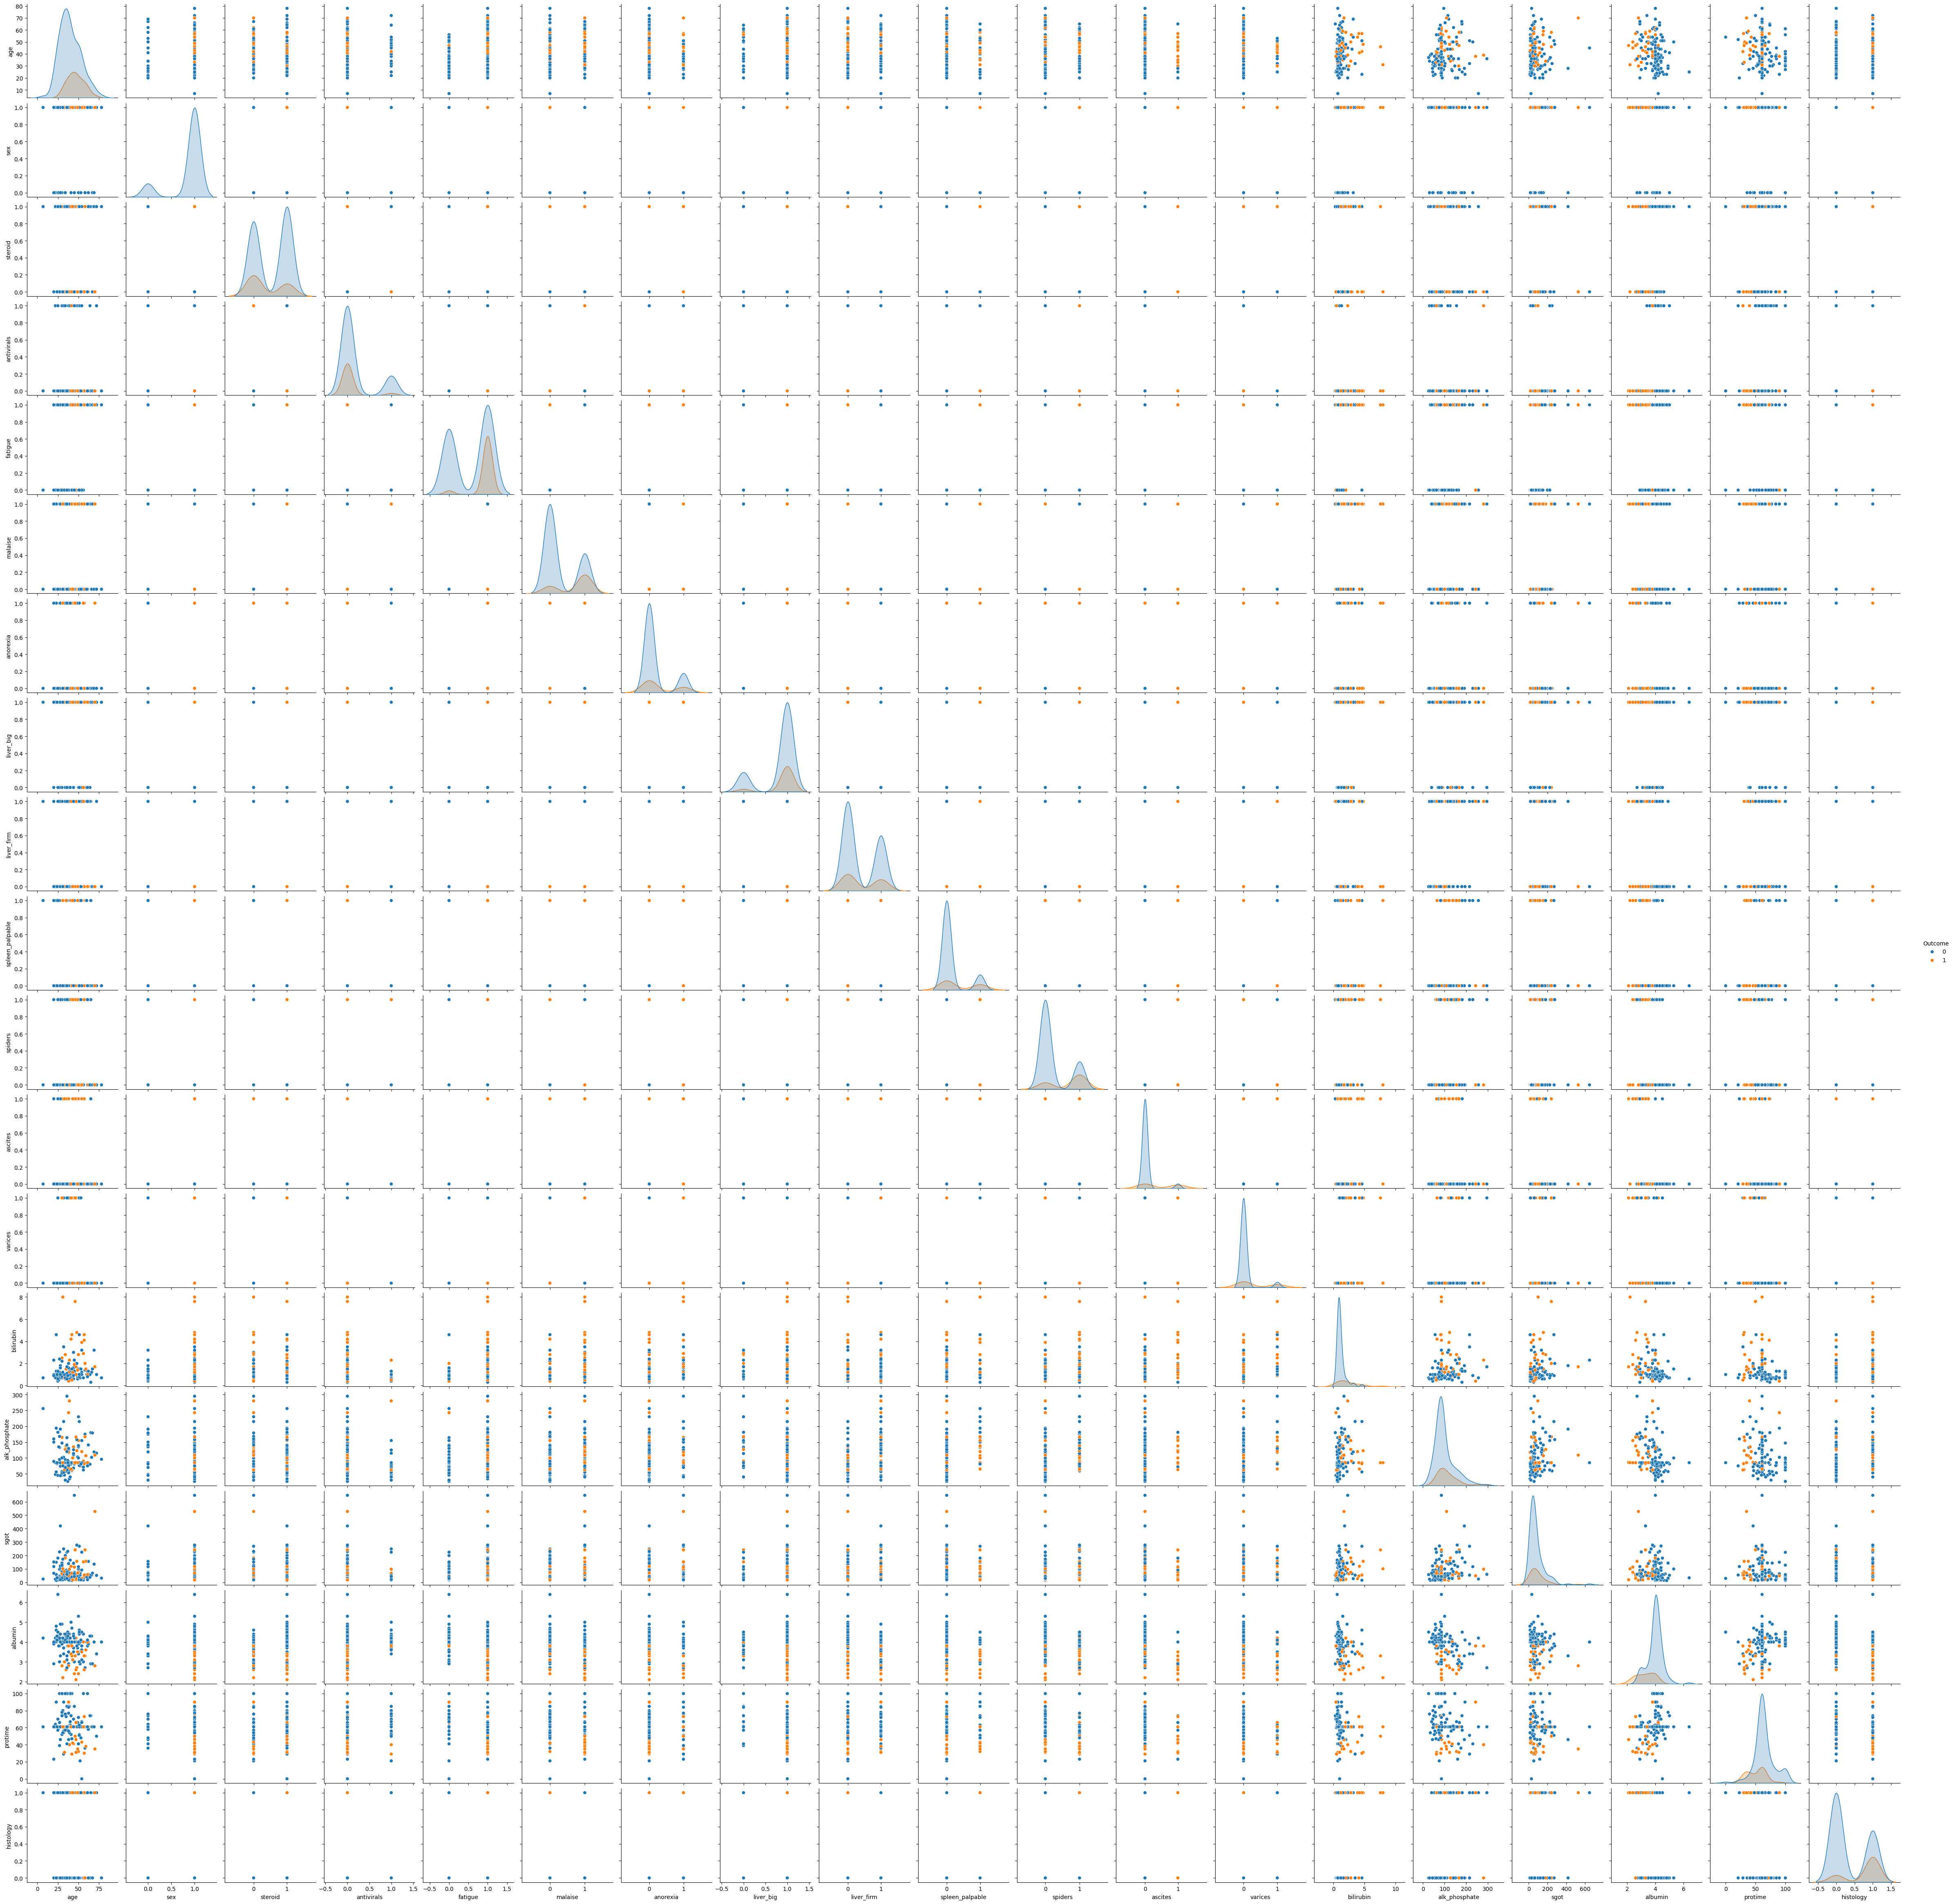

In [116]:
sns.pairplot(data=df, hue='Outcome')

#### Spearman Rank Correlation

<Axes: >

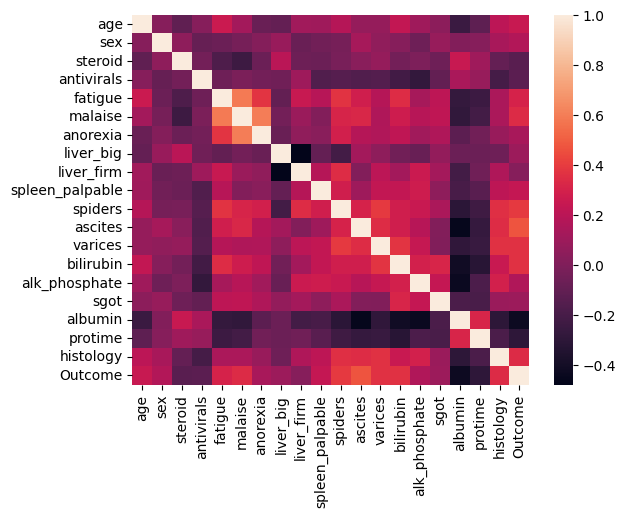

In [117]:
corr = df.corr(method="spearman")
sns.heatmap(corr,annot=False)

In [118]:
df['sex'].value_counts()

sex
1    139
0     16
Name: count, dtype: int64

* We impute outlier values using **IQR(Interquartile Range Method)**

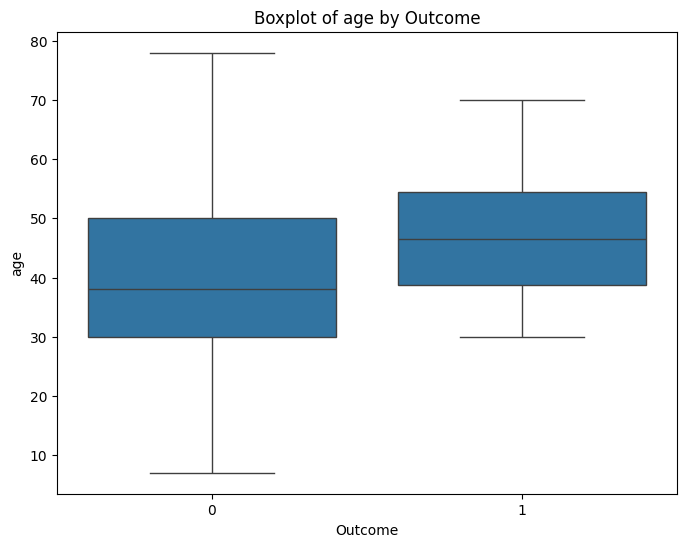

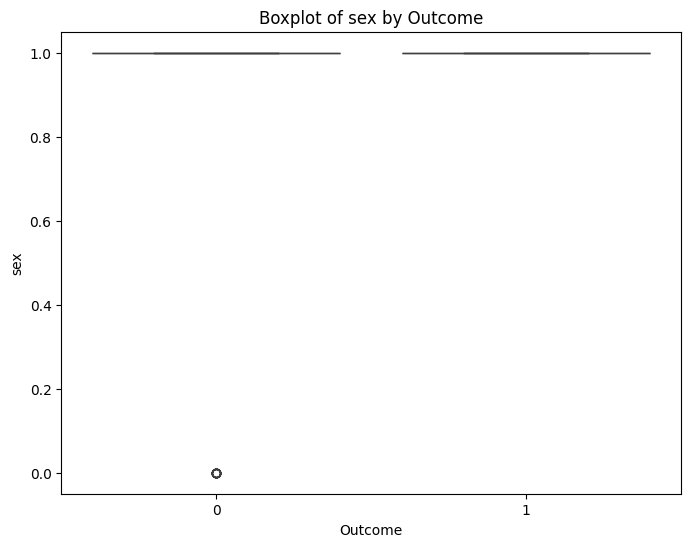

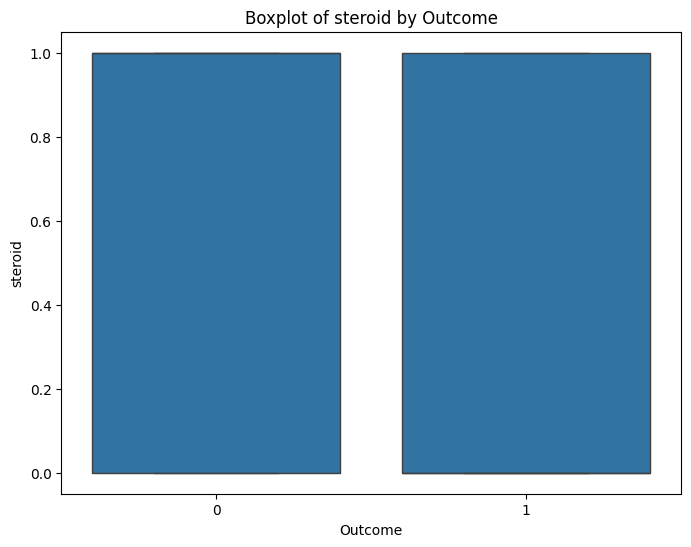

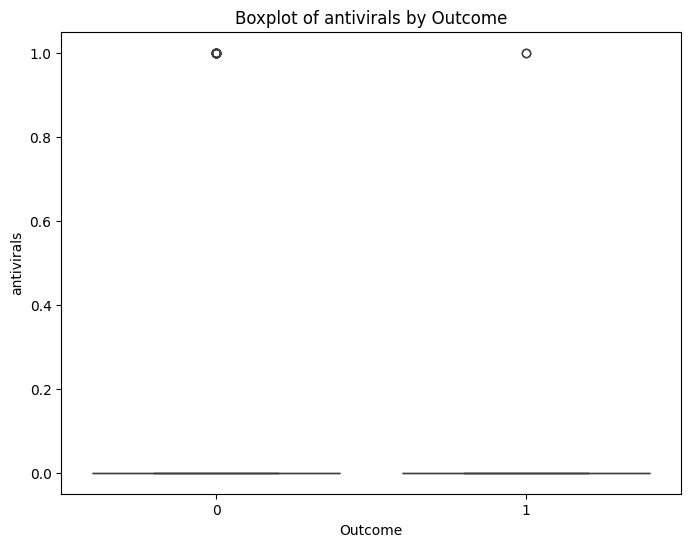

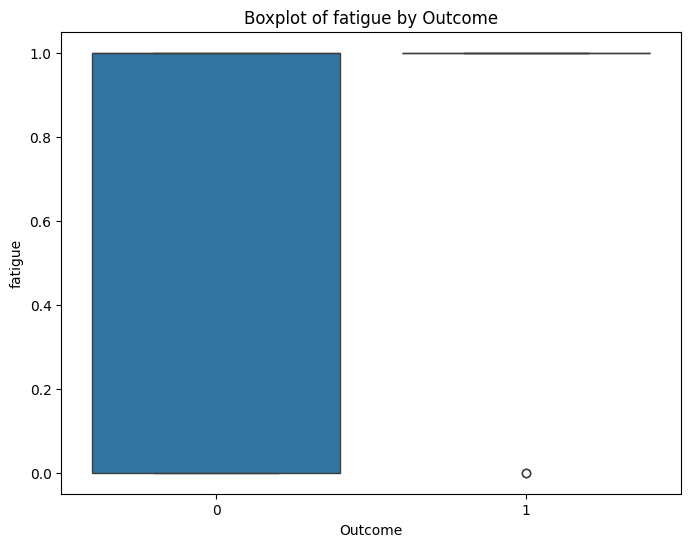

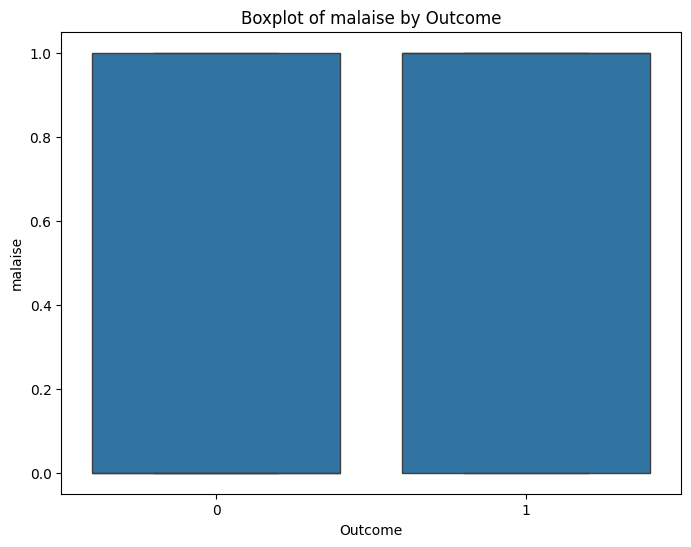

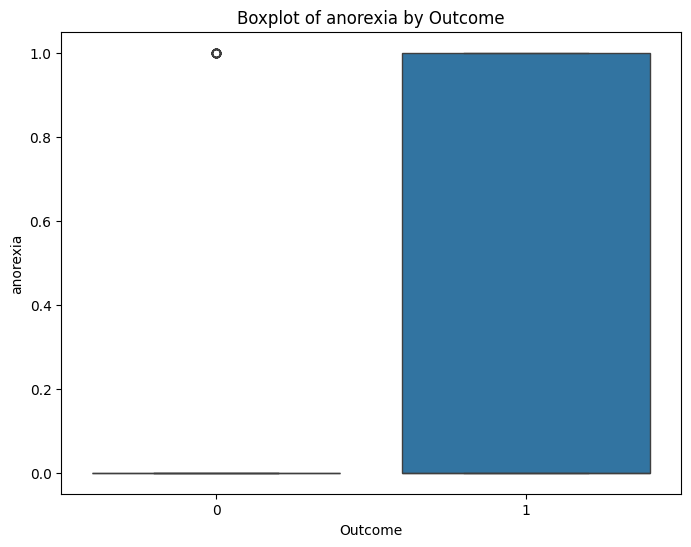

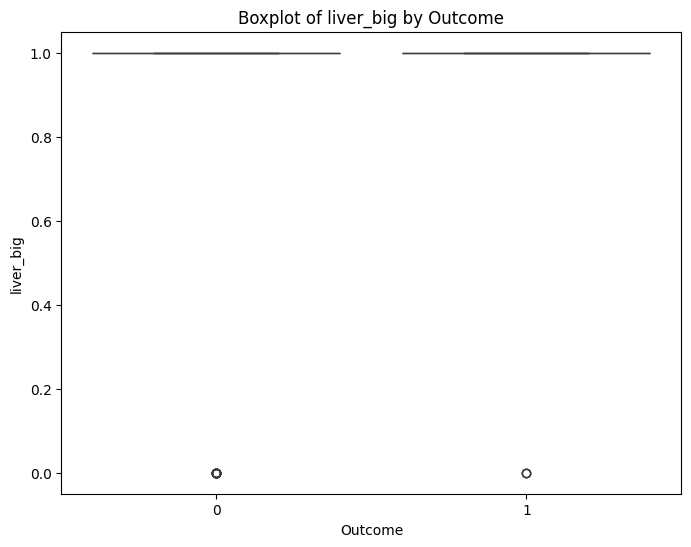

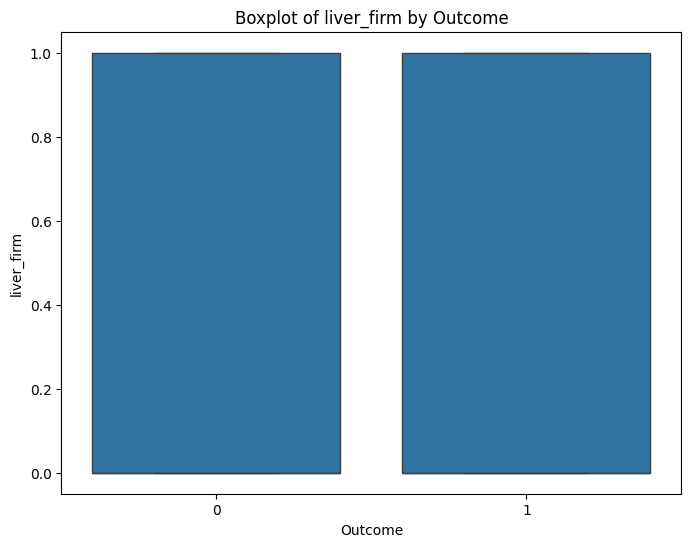

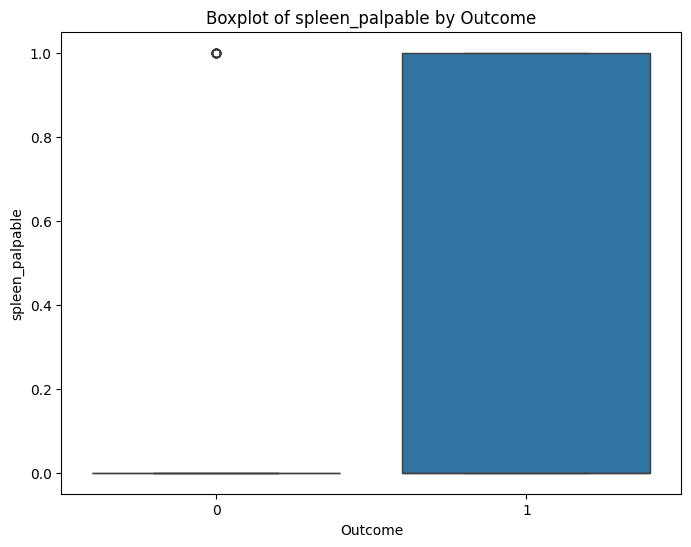

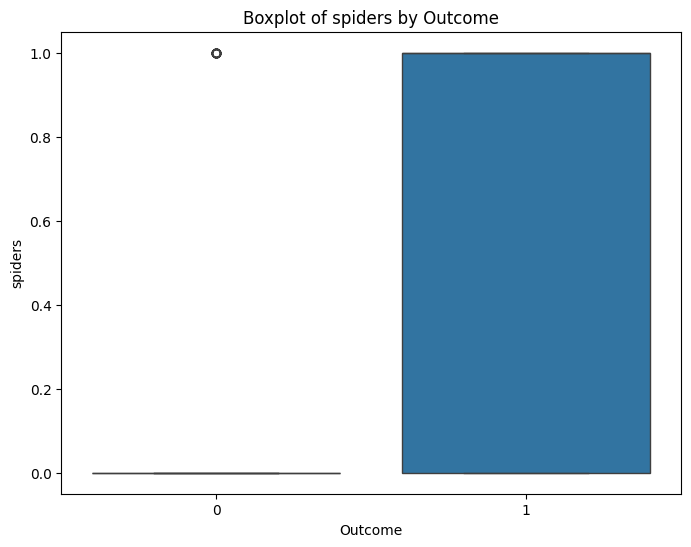

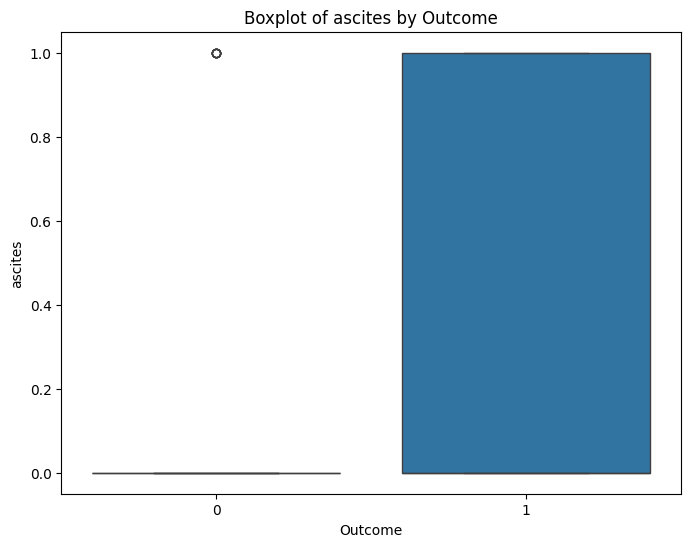

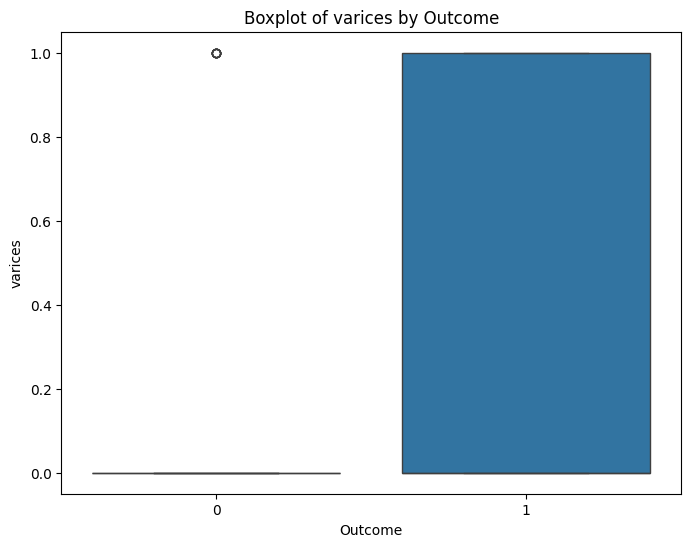

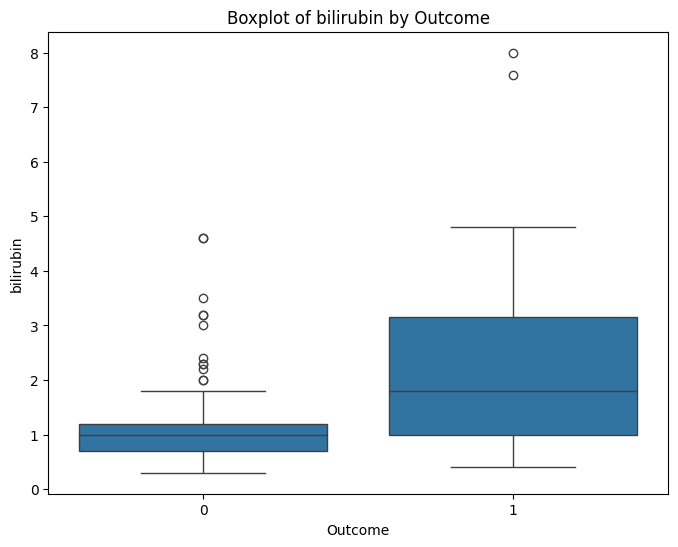

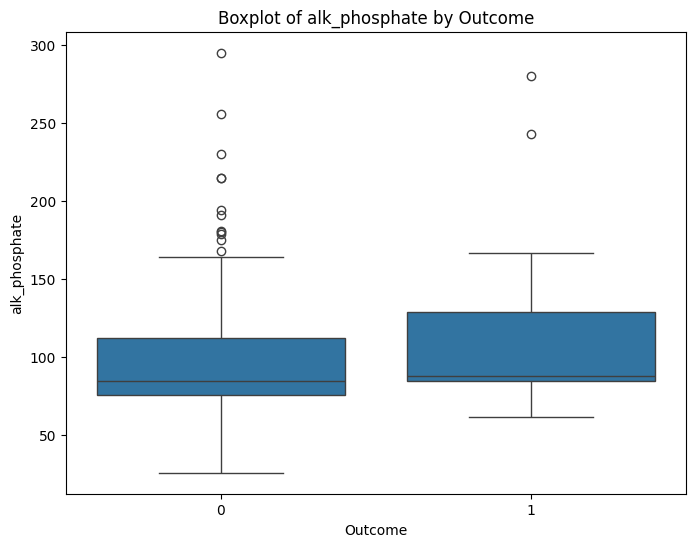

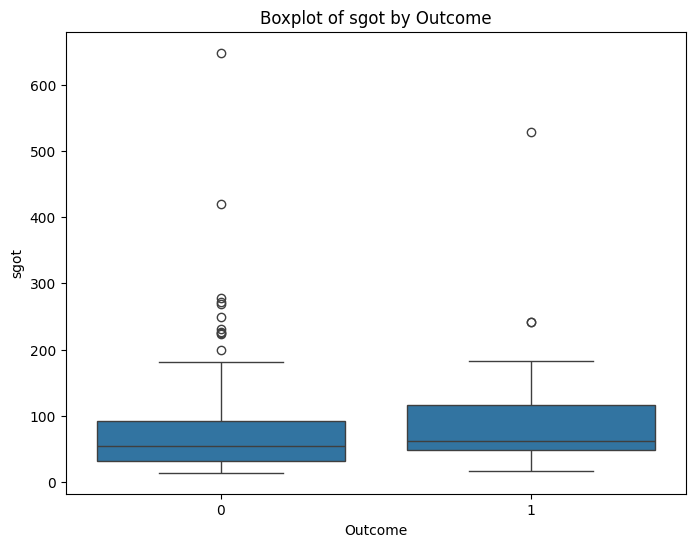

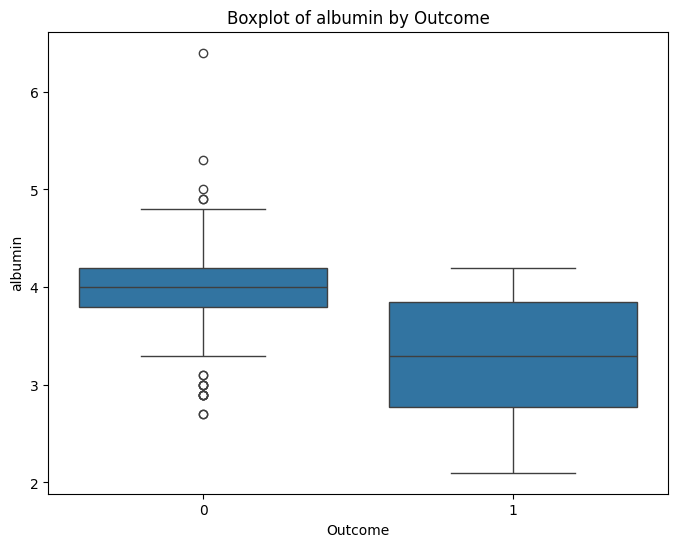

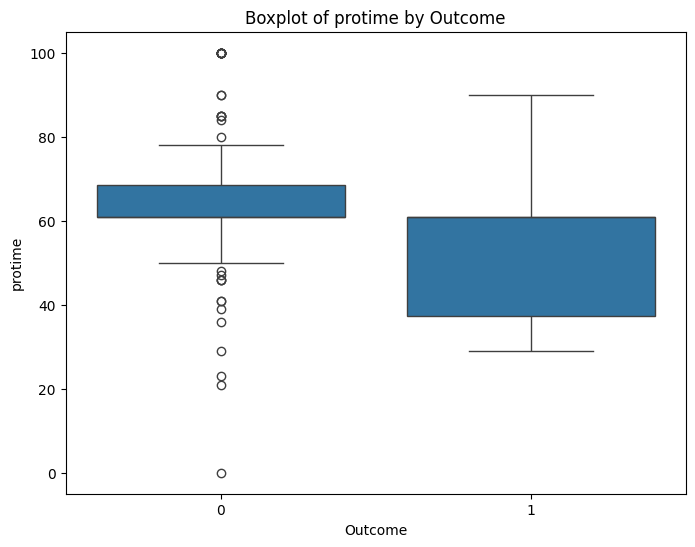

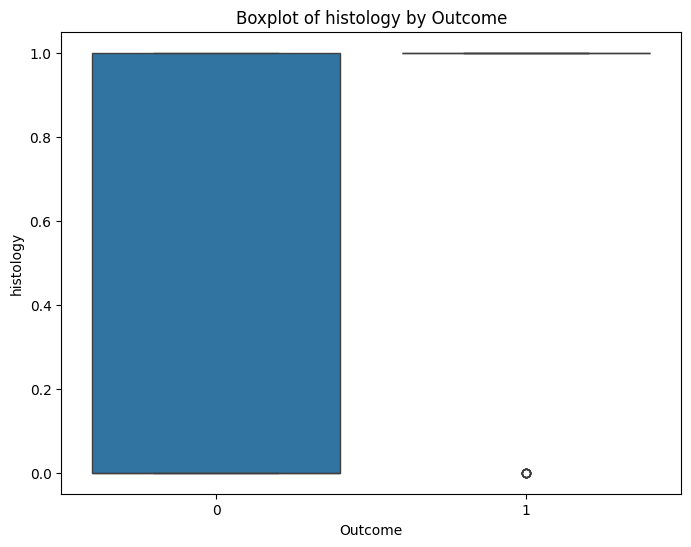

In [119]:
cols = [col for col in df.columns if col!="Outcome"]
for col in cols:
        plt.figure(figsize=(8, 6))
        sns.boxplot(data=df, x="Outcome", y=col)
        plt.title(f'Boxplot of {col} by Outcome')
        plt.show()

In [120]:
def removeOutlier(col):
    sorted(col)
    quant1, quant2 = col.quantile([0.25, 0.75])
    IQR = quant2 - quant1
    lowerRange = quant1 - (1.5 * IQR)
    upperRange = quant2 + (1.5 * IQR)
    return lowerRange, upperRange

In [121]:
df.describe()

,age,sex,steroid,fatigue,malaise,anorexia,liver_big,liver_firm,spleen_palpable,spiders,ascites,varices,bilirubin,alk_phosphate,sgot,albumin,protime,Outcome
count,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000
mean,41.200000,0.896774,0.509677,0.651613,0.393548,0.206452,0.838710,0.387097,0.193548,0.329032,0.129032,0.116129,1.410968,101.522581,85.174194,3.836129,61.483871,0.206452
std,12.565878,0.305240,0.501527,0.478004,0.490120,0.406070,0.368991,0.488665,0.396360,0.471385,0.336322,0.321418,1.191178,47.082042,88.590122,0.619267,17.198745,0.406070
min,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.300000,26.000000,14.000000,2.100000,0.000000,0.000000
25%,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.800000,78.000000,32.500000,3.500000,57.000000,0.000000
50%,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,85.000000,58.000000,4.000000,61.000000,0.000000
75%,50.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.500000,119.500000,99.000000,4.200000,65.000000,0.000000
max,78.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,295.000000,648.000000,6.400000,100.000000,1.000000


In [129]:
# Define the function to calculate IQR and remove outliers
def removeOutlier(series):
    # Ensure the input is numeric
    if not pd.api.types.is_numeric_dtype(series):
        raise ValueError(f"Column {series.name} is not numeric.")
    
    # Calculate the IQR
    quant1, quant2 = series.quantile([0.25, 0.75])
    IQR = quant2 - quant1
    lower_bound = quant1 - 1.5 * IQR
    upper_bound = quant2 + 1.5 * IQR
    
    return lower_bound, upper_bound

# List of columns to process
num_cols = ['albumin', 'protime', 'bilirubin', 'age', 'histology', 'sgot', 'alk_phosphate']

# Apply outlier removal for each column
for col in num_cols:
    try:
        # Check if the column exists and is numeric
        if col in df.columns:
            lowScore, highScore = removeOutlier(df[col])
            print(f"Column: {col}, Lower Bound: {lowScore}, Upper Bound: {highScore}")
            
            # Replace outliers with the nearest bound
            df[col] = np.where(df[col] > highScore, highScore, 
                               np.where(df[col] < lowScore, lowScore, df[col]))
        else:
            print(f"Column {col} not found in the DataFrame.")
    except Exception as e:
        print(f"Error processing column {col}: {e}")

Column: albumin, Lower Bound: 2.4499999999999997, Upper Bound: 5.25
Column: protime, Lower Bound: 45.0, Upper Bound: 77.0
Column: bilirubin, Lower Bound: -0.24999999999999978, Upper Bound: 2.55
Column: age, Lower Bound: 5.0, Upper Bound: 77.0
Error processing column histology: numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xor function instead.
Column: sgot, Lower Bound: -67.25, Upper Bound: 198.75
Column: alk_phosphate, Lower Bound: 15.75, Upper Bound: 181.75


In [130]:
df['histology'].value_counts()

histology
False    85
True     70
Name: count, dtype: int64

In [139]:
df['antivirals'].value_counts()

antivirals
False    131
True      24
Name: count, dtype: int64

In [131]:
df['histology'] = df['histology'].astype(bool)

# Now, 'histology' is a boolean column
print(df['histology'].dtype)

bool


In [140]:
#antivirals
df['antivirals'] = df['antivirals'].astype(bool)

# Now, 'antivirals' is a boolean column
print(df['antivirals'].dtype)

bool


In [141]:
df['antivirals']=df['antivirals'].map(mapping_2)

In [133]:
df['histology']=df['histology'].map(mapping_2)

In [134]:
# Define the function to calculate IQR and remove outliers
def removeOutlier(series):
    # Ensure the input is numeric
    if not pd.api.types.is_numeric_dtype(series):
        raise ValueError(f"Column {series.name} is not numeric.")
    
    # Calculate the IQR
    quant1, quant2 = series.quantile([0.25, 0.75])
    IQR = quant2 - quant1
    lower_bound = quant1 - 1.5 * IQR
    upper_bound = quant2 + 1.5 * IQR
    
    return lower_bound, upper_bound

# List of columns to process
num_cols = ['albumin', 'protime', 'bilirubin', 'age', 'sgot', 'alk_phosphate']

# Apply outlier removal for each column
for col in num_cols:
    try:
        # Check if the column exists and is numeric
        if col in df.columns:
            lowScore, highScore = removeOutlier(df[col])
            print(f"Column: {col}, Lower Bound: {lowScore}, Upper Bound: {highScore}")
            
            # Replace outliers with the nearest bound
            df[col] = np.where(df[col] > highScore, highScore, 
                               np.where(df[col] < lowScore, lowScore, df[col]))
        else:
            print(f"Column {col} not found in the DataFrame.")
    except Exception as e:
        print(f"Error processing column {col}: {e}")

Column: albumin, Lower Bound: 2.4499999999999997, Upper Bound: 5.25
Column: protime, Lower Bound: 45.0, Upper Bound: 77.0
Column: bilirubin, Lower Bound: -0.24999999999999978, Upper Bound: 2.55
Column: age, Lower Bound: 5.0, Upper Bound: 77.0
Column: sgot, Lower Bound: -67.25, Upper Bound: 198.75
Column: alk_phosphate, Lower Bound: 15.75, Upper Bound: 181.75


* **Check if the outliers are handled**

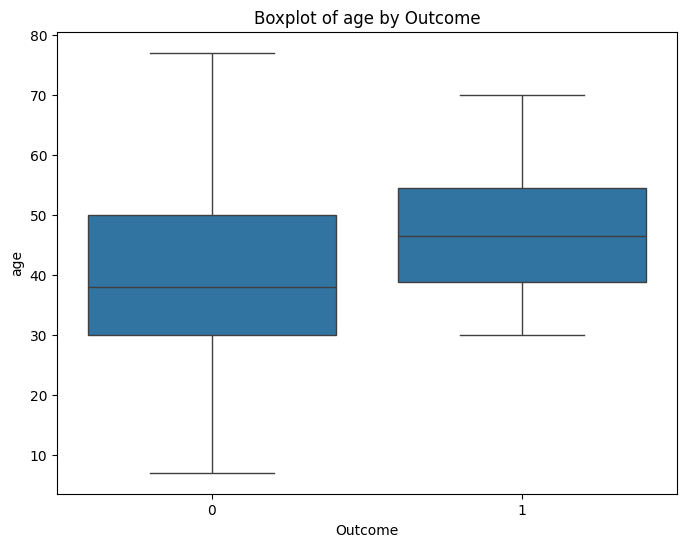

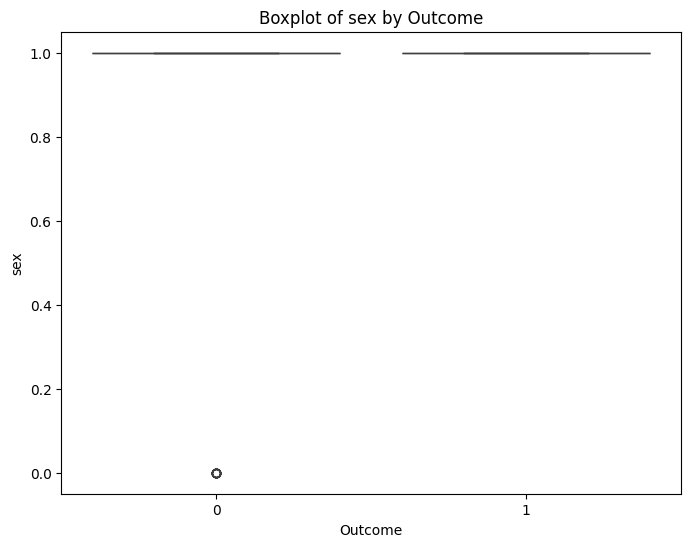

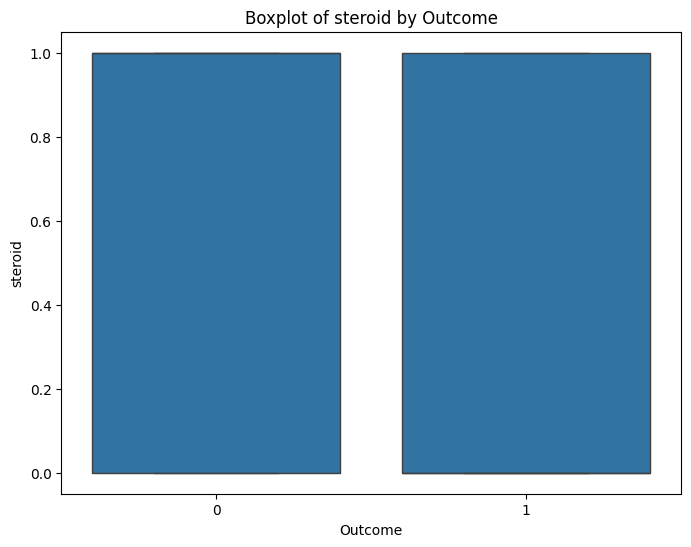

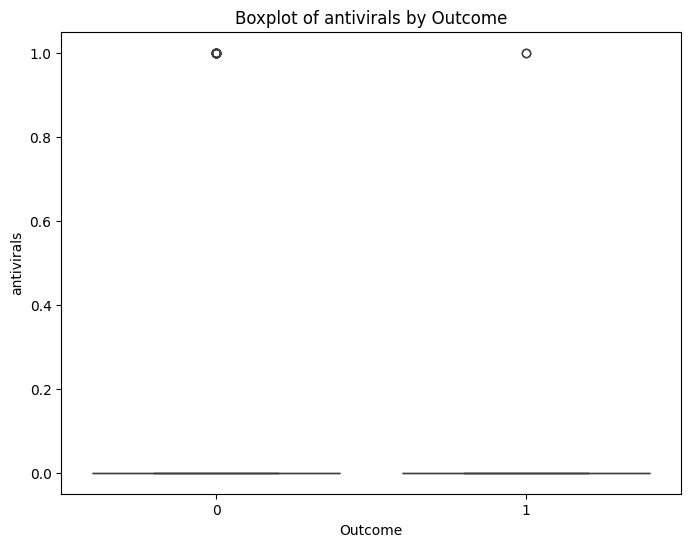

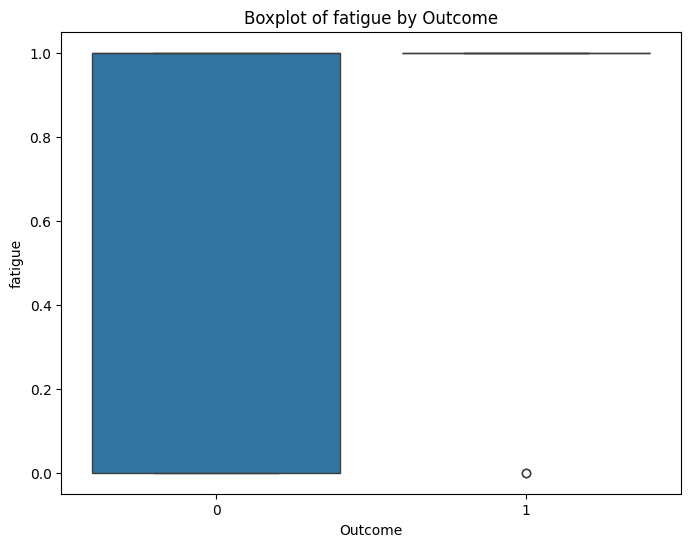

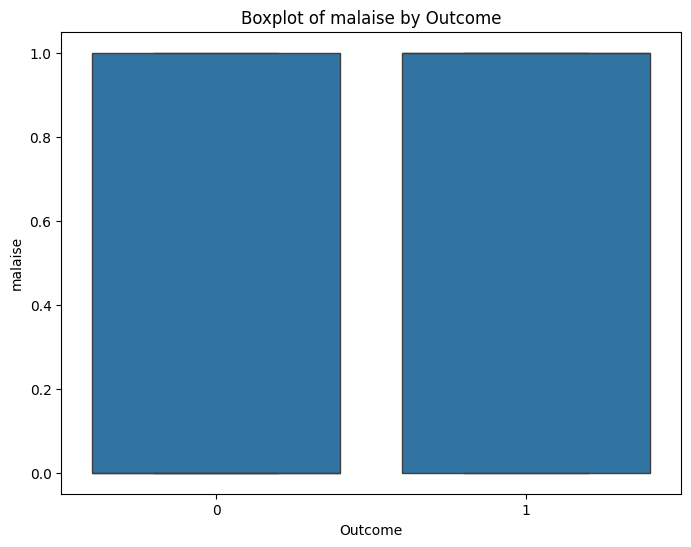

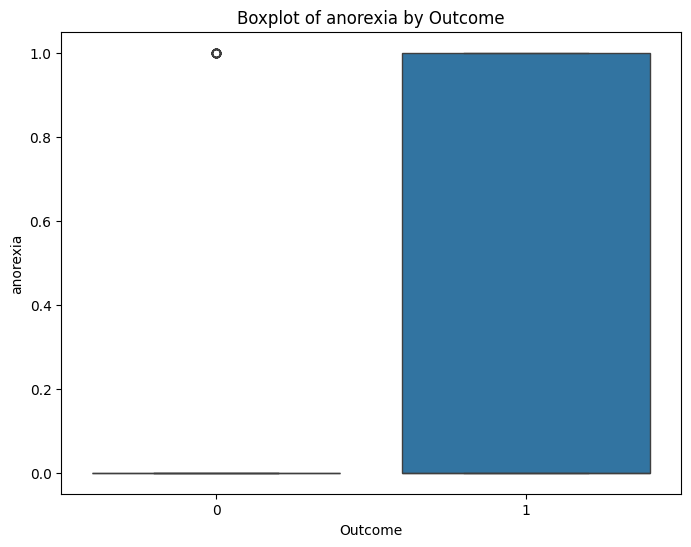

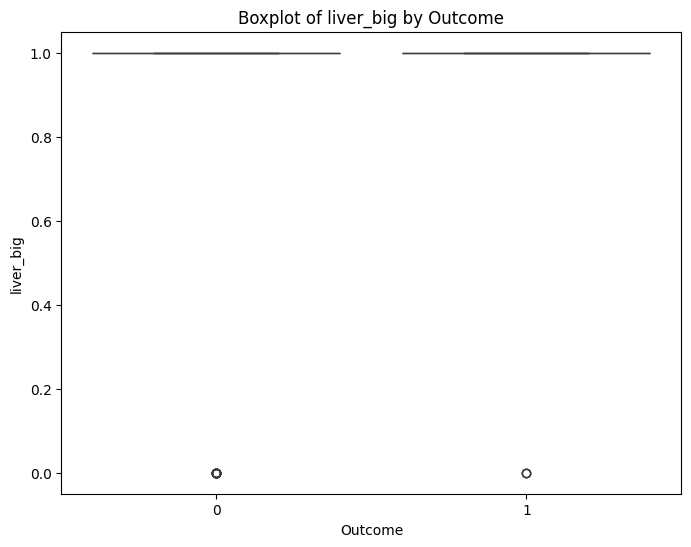

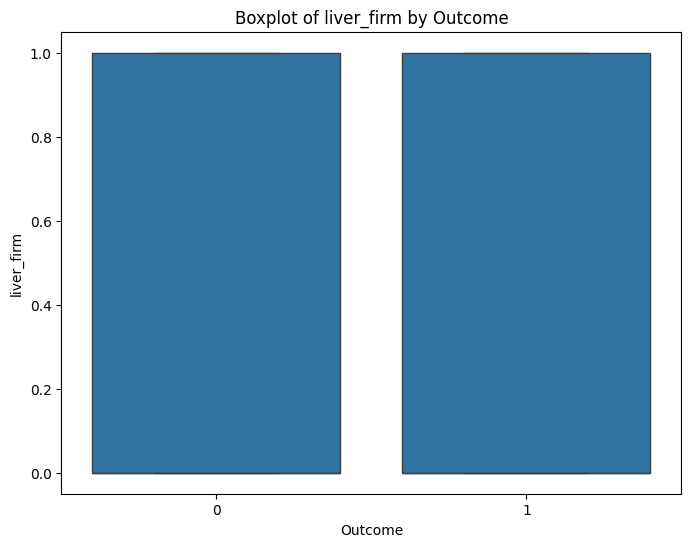

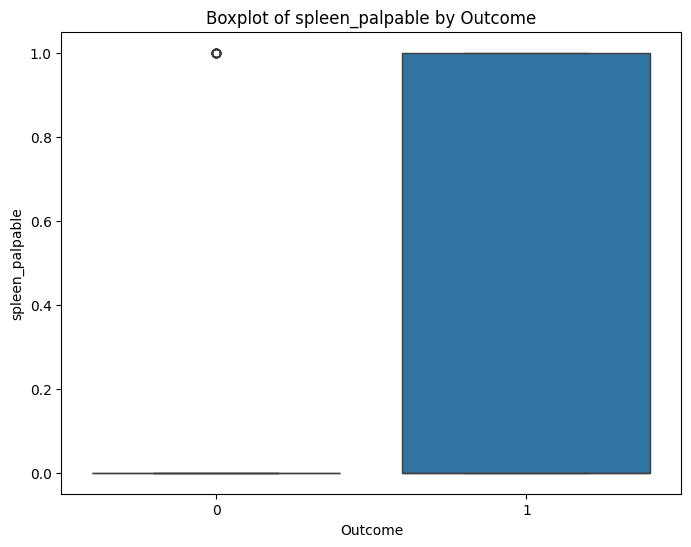

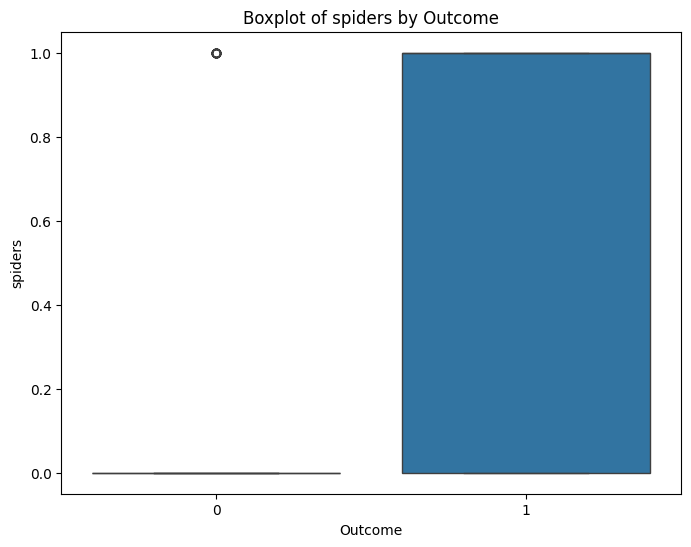

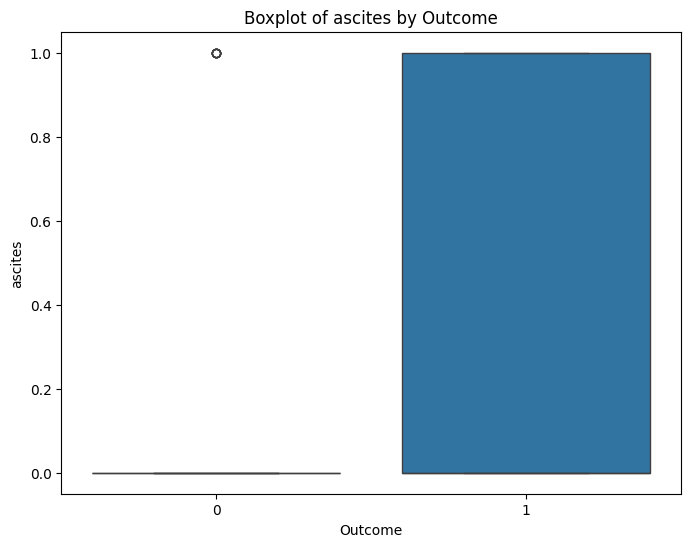

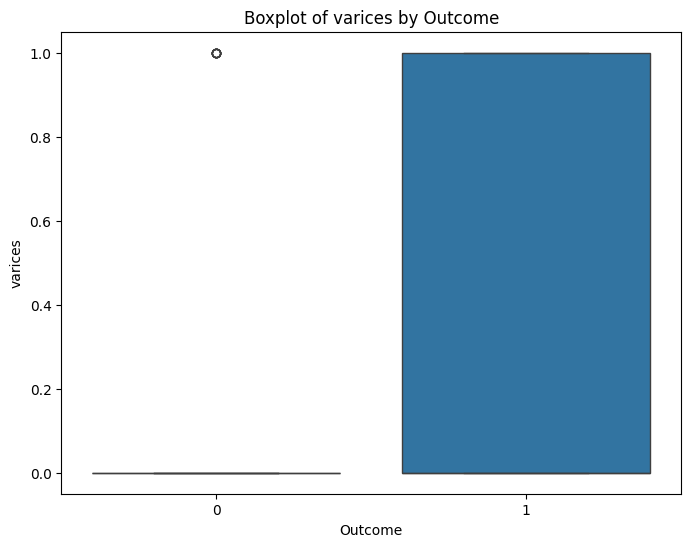

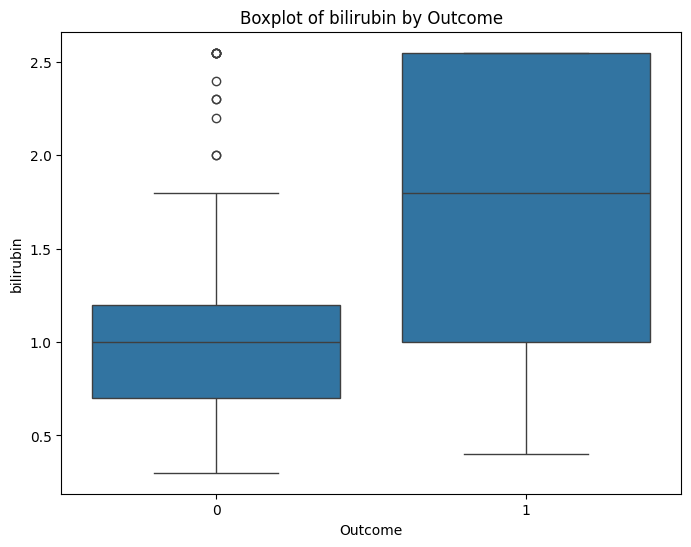

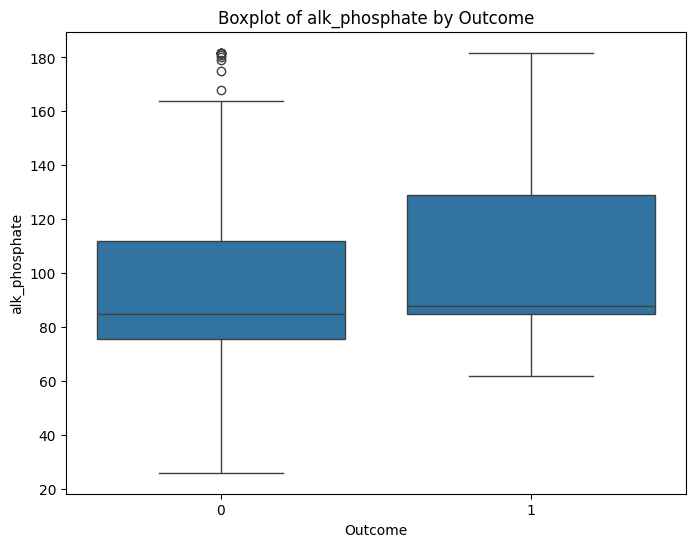

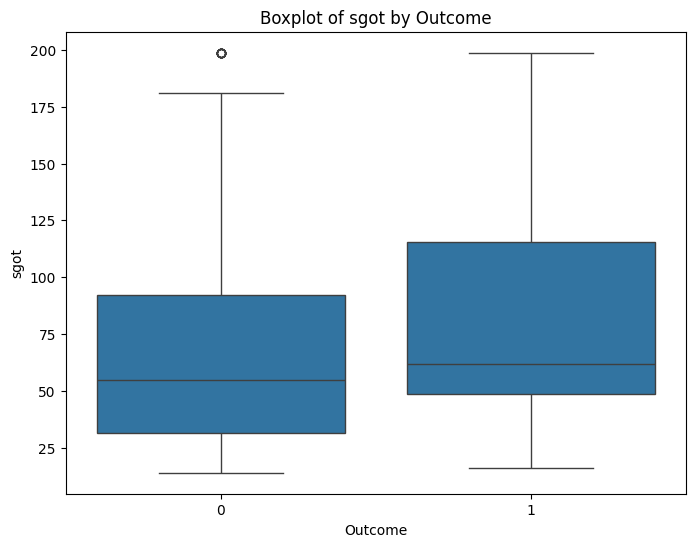

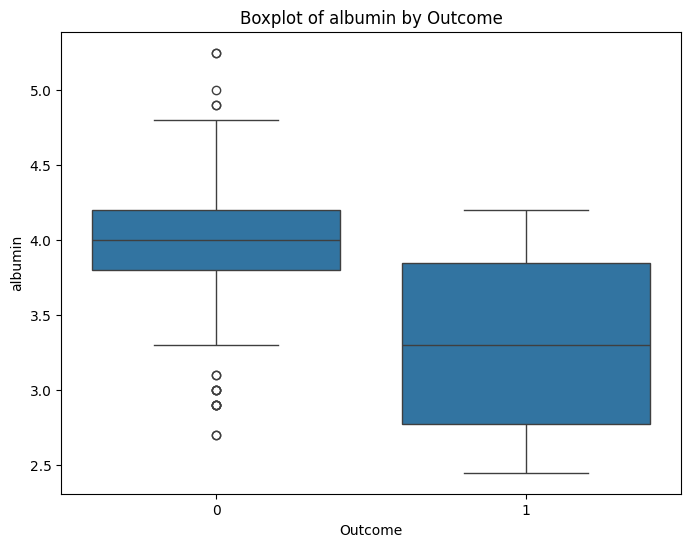

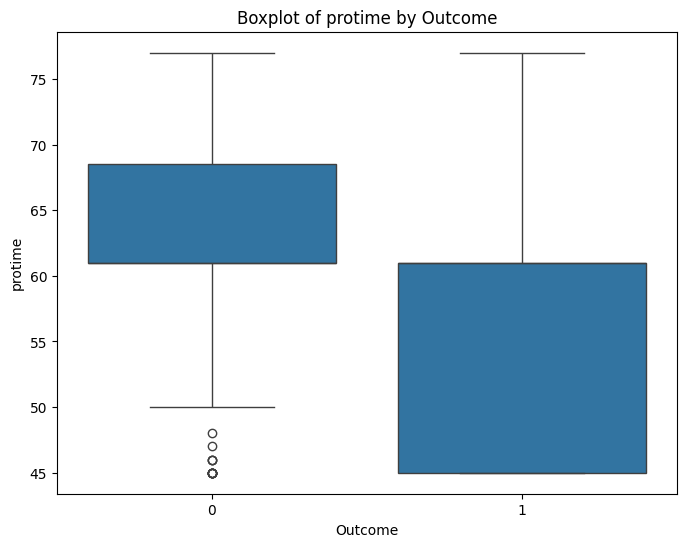

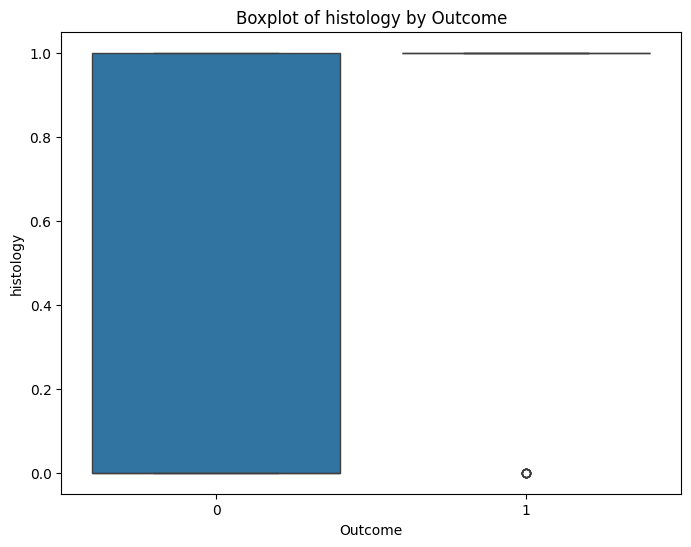

In [135]:
cols = [col for col in df.columns if col!="Outcome"]
for col in cols:
        plt.figure(figsize=(8, 6))
        sns.boxplot(data=df, x="Outcome", y=col)
        plt.title(f'Boxplot of {col} by Outcome')
        plt.show()

In [136]:
df.describe()

,age,sex,steroid,fatigue,malaise,anorexia,liver_big,liver_firm,spleen_palpable,spiders,ascites,varices,bilirubin,alk_phosphate,sgot,albumin,protime,histology,Outcome
count,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000
mean,41.193548,0.896774,0.509677,0.651613,0.393548,0.206452,0.838710,0.387097,0.193548,0.329032,0.129032,0.116129,1.223548,98.404839,75.680645,3.832903,60.980645,0.451613,0.206452
std,12.547104,0.305240,0.501527,0.478004,0.490120,0.406070,0.368991,0.488665,0.396360,0.471385,0.336322,0.321418,0.627645,38.292293,55.557976,0.582244,9.860370,0.499266,0.406070
min,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.300000,26.000000,14.000000,2.450000,45.000000,0.000000,0.000000
25%,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.800000,78.000000,32.500000,3.500000,57.000000,0.000000,0.000000
50%,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,85.000000,58.000000,4.000000,61.000000,0.000000,0.000000
75%,50.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.500000,119.500000,99.000000,4.200000,65.000000,1.000000,0.000000
max,77.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.550000,181.750000,198.750000,5.250000,77.000000,1.000000,1.000000


### save the preprocessed dataset "Hepatitis_processed.csv"

In [142]:
df.head()

,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver_big,liver_firm,spleen_palpable,spiders,ascites,varices,bilirubin,alk_phosphate,sgot,albumin,protime,histology,Outcome
0,30.0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,85.0,18.00,4.0,61.0,0,0
1,50.0,1,0,0,1,0,0,0,0,0,0,0,0,0.9,135.0,42.00,3.5,61.0,0,0
2,77.0,1,1,0,1,0,0,1,0,0,0,0,0,0.7,96.0,32.00,4.0,61.0,0,0
3,31.0,1,1,1,0,0,0,1,0,0,0,0,0,0.7,46.0,52.00,4.0,77.0,0,0
4,34.0,1,1,0,0,0,0,1,0,0,0,0,0,1.0,85.0,198.75,4.0,61.0,0,0


In [143]:
df.to_csv(path_or_buf="Hepatitis_processed.csv")